In [2]:
import numpy as np 
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt 

First 5 entries:
190.7 0.847 2.73 191.138412
198.4 0.968 2.89 192.730133
206.6 1.11 3.05 194.321869
207.3 1.036 2.928 195.913666
208.0 1.046 2.944 197.505493

Total points read: 240


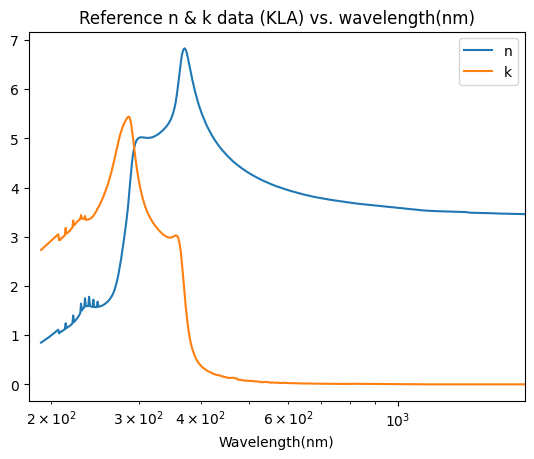

In [7]:
# Filename (update path if needed)
filename = r"C:\School Stuff\UC Davis\Leite Lab\Data\si.txt"

# Containers
wavelength_nm = []
n_vals = []
k_vals = []

#extracts data from multiple columns 
with open(filename, "r") as f:
    header = f.readline()  # skip header line
    for line in f:
        if not line.strip():
            continue  # skip empty lines

        wl, n, k = line.split()
        wavelength_nm.append(float(wl))
        n_vals.append(float(n))
        k_vals.append(float(k))

# Read the second file with single column
second_filename = r"C:\School Stuff\UC Davis\Leite Lab\Data\Wavelength Range for Interpolation.txt"
interpolation_range = []
with open(second_filename, "r") as f:
    header = f.readline()  # skip header line
    for line in f:
        if not line.strip():
            continue  # skip empty lines
        value = line.strip()
        interpolation_range.append(float(value))


# Quick sanity check
print("First 5 entries:")
for i in range(5):
    print(wavelength_nm[i], n_vals[i], k_vals[i], interpolation_range[i])

print(f"\nTotal points read: {len(wavelength_nm)}")


#checking the plots
plt.title("Reference n & k data (KLA) vs. wavelength(nm)")
plt.xlabel("Wavelength(nm)")
plt.plot(wavelength_nm, n_vals, label = 'n')
plt.plot(wavelength_nm, k_vals, label = 'k') 
plt.legend()
plt.xlim(180, 1800)
plt.xscale('log')
plt.show()


### Spline interpolation 

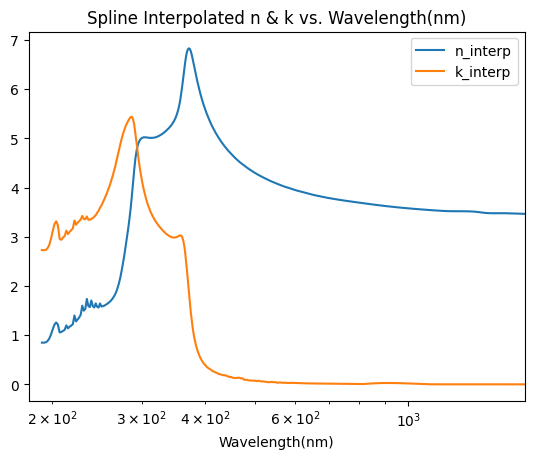

In [5]:
# Your irregularly spaced data
wavelengths1= np.array(wavelength_nm) #wavelengths from n-k reference 
n_data = np.array(n_vals) #n & k data of silicon 
k_data = np.array(k_vals) 

# Create the splines for fitting 
cs_n = CubicSpline(wavelengths1, n_data, bc_type='clamped')
cs_k = CubicSpline(wavelengths1, k_data, bc_type='clamped')

# Interpolate at any x values(wavelengths) within your range
wavelengths_new = np.array(interpolation_range)  # points you want to fill in (i.e., Margaret's wavelengths) 
n_new = cs_n(wavelengths_new)
k_new = cs_k(wavelengths_new)

plt.title("Spline Interpolated n & k vs. Wavelength(nm)")
plt.xlabel("Wavelength(nm)")
plt.plot(wavelengths_new, n_new, label = 'n_interp')
plt.plot(wavelengths_new, k_new, label = 'k_interp')
plt.legend()
plt.xlim(180, 1689.00)
plt.xscale('log')
plt.show()

https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.CubicSpline.html

### 'Pchip interpolation' 

* https://en.wikipedia.org/wiki/Monotone_cubic_interpolation
* https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.PchipInterpolator.html
* https://docs.scipy.org/doc/scipy/tutorial/interpolate.html

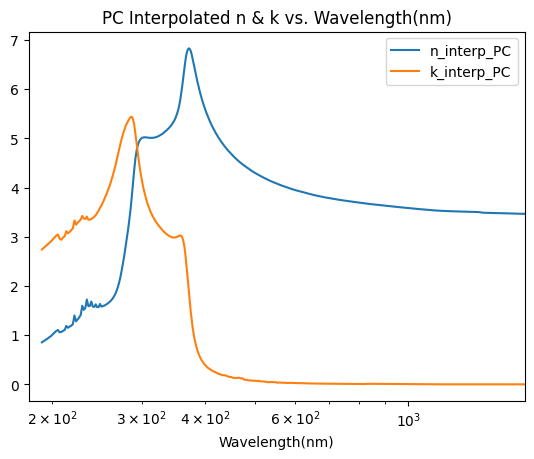

In [6]:
from scipy.interpolate import PchipInterpolator

pchip_n = PchipInterpolator(wavelengths1, n_data)
pchip_k = PchipInterpolator(wavelengths1, k_data)

n_new_PC = pchip_n(wavelengths_new)
k_new_PC = pchip_k(wavelengths_new)

plt.title("PC Interpolated n & k vs. Wavelength(nm)")
plt.xlabel("Wavelength(nm)")
plt.plot(wavelengths_new, n_new_PC, label = 'n_interp_PC')
plt.plot(wavelengths_new, k_new_PC, label = 'k_interp_PC')
plt.legend()
plt.xlim(180, 1689.00)
plt.xscale('log')
plt.show()

**Schematic of the Structure**
* Is a four layer structure where:
    * **First Layer** is Air 
    * **Second Layer** is the Oxide (**simulate first at 10nm, all the way up to 100 nm in increments of 10 nm**)
    * **Third Layer** is the refractory metal (**fixed thickness of 20nm**) 
    * **Fourth Layer** is the Silicon substrate of arbitrary thickness
* I will in total need 5 matrices to describe the whole structure because there are three interfaces
    * Air/oxide Interface --> One Transmission matrix 
    * Electric Field propagating through the Oxide --> One Propagation Matrix
    * Oxide/Metal Interface --> Second Transmission Matrix
    * Electric Field Propagating through Metal --> Second Propagation Matrix
    * Metal/Silicon Interface --> Third Transmission Matrix

**Work-Flow**
* **1)** calculate the complex refractive index given the dielectric function data (would need to do this for each wavelength, and for each material)
    * Make sure to do this for both the oxide and the metal 
* **2)** calculate the angle of $\theta_{transmitted}$ using Snell's law
    * For the first interface, n=1 for air, and then $n_{oxide}$ is calculated from previous step
    * For the second interface, $n_{oxide}$ and $n_{metal}$ is calculated from previous step, the 'incident angle' here is equivalent to the $\theta_{transmitted}$ of the previous step
    * Last interface (Metal/Silicon) we are not concerned with the propagation of E-field through it 
* **3)** calculate the transmission and reflection coefficients for s and p polarizations of the E-field and store them
* **4)** calculate $\phi_{j}$ using previous data, and input the layer thickness (can initialize a list of these for the oxide)
* **5)** calculate the propagation matrices using inputs from steps 1 and 2 
    * For this, make sure to get use the correct $\theta_{transmitted}$ for the oxide and metal layers
* **6)** calculate the transmission matrices (steps 5 and 6 are independent of eachother)
    * remember to calculate three of them
    * The n-k data for silicon at each wavelength is obtained from https://www.kla.com/products/instruments/refractive-index-database/Si/Silicon
* **7)** Multiply the matrices as follows for BOTH s and p-polarized light 

$$ 
M_{\text{total}} = M_{\text{transmit, Air} \to Oxide} \cdot M_{\text{prop, Oxide}} \cdot M_{\text{transmit, Oxide} \to Metal} \cdot M_{\text{prop, Metal}} \cdot M_{\text{transmit, Metal} \to \text{Si}}
$$

* **8)** Calculate the Reflectivity for S & P polarizations using the matrix elements
* **9)** Average the values in step 8) to obtain the average polarization describing the light wave 
* **10)** Store the value in some array. This corresponds to a specific wavelength
* **11)** Loop over an array of wavelengths to obtain all the values and store them
* **12)** Plot these values against wavelength and then scale the graph as needed to compare

side notes:
* Need the wavelength array to be in the parent loop, then the thickness array(s) to be in the secondary loops.


$$ 
M_{\text{total}} = D_{\text{Air} \to \text{Oxide}} \cdot P_{\text{Oxide}} \cdot D_{\text{Oxide} \to \text{Metal}} \cdot P_{\text{Metal}} \cdot D_{\text{Metal} \to \text{Si}}
$$

$$
n = \sqrt{\epsilon_{r}} = \sqrt{\epsilon' - j\epsilon''}
$$ 

$$
n_{j}sin(\theta_{j}) = n_{j+1}sin(\theta_{j+1})
$$ 

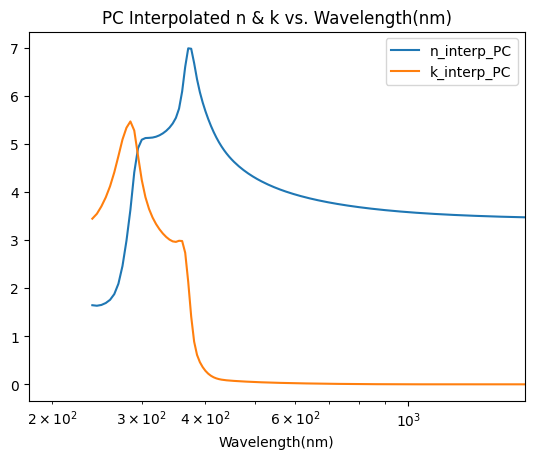

In [7]:
#silicon n-k data extraction
ref_silicon = r"C:\School Stuff\UC Davis\Leite Lab\Data\Si_measured.txt"

# Containers/the columns of your data
wavelength_nm_silicon= []
e1_vals_si = []
e2_vals_si = []


#extracts data from multiple columns 
with open(ref_silicon , "r") as f: #opens file = 'filename' in readmode --> 'r' and assigns this to a variable, f 
    header = f.readline()  # reads 'one complete HORIZONTAL line' in the file and stores that information in the'header' variable, as this is usually header information. 
    for line in f: #the first horizontal line is read, so now the file pointer is on line two. It will now to start to loop line by line. 
        if not line.strip():
            continue  # line.strip just removes any spaces, commas, etc. that are in the line, and then if the line is empty, it gets skipped over, and the next line is examined 

        wl, e1, e2 = line.split() #the horizontal line is split into columns now, and you WILL alter this for your data file to extract column info line by line(row by row). 
        wavelength_nm_silicon.append(float(wl))
        e1_vals_si.append(float(e1))
        e2_vals_si.append(float(e2))\
        
e1_si = np.array(e1_vals_si)
e2_si = np.array(e2_vals_si) 

n_complex = np.sqrt(e1_si + 1j* e2_si)
n_real_si = n_complex.real 
n_imag_si = n_complex.imag

plt.title("PC Interpolated n & k vs. Wavelength(nm)")
plt.xlabel("Wavelength(nm)")
plt.plot(wavelength_nm_silicon, n_real_si, label = 'n_interp_PC')
plt.plot(wavelength_nm_silicon, n_imag_si, label = 'k_interp_PC')
plt.legend()
plt.xlim(180, 1689.00)
plt.xscale('log')
plt.show()



In [6]:
print(n_real_si)

[1.47361723 1.2970919  1.11594646 0.9425665  0.76959697 0.79006171
 1.30770857 2.27762269 3.51027832 4.78733244 6.16707209 6.93975512
 7.14049567 7.1340911  7.0921697  7.06084527 7.04836388 7.0542573
 7.07716072 7.11733421 7.17779252 7.26507591 7.39630863 7.62446782
 8.02828088 8.49610159 8.6011413  8.14283108 7.45913472 6.89842028
 6.49960698 6.19325053 5.93995387 5.72544133 5.5426365  5.38664369
 5.25327166 5.13884157 5.04001904 4.95387303 4.87801484 4.81030972
 4.74926445 4.6936433  4.64254216 4.59532254 4.5514485  4.51058387
 4.47235073 4.43651469 4.4028409  4.37108507 4.34113878 4.31278247
 4.28598553 4.2605203  4.23638683 4.21337951 4.19148727 4.17062918
 4.15068862 4.13164689 4.11344084 4.09599064 4.07925762 4.06324306
 4.04785731 4.03304865 4.01882689 4.00512947 3.99195357 3.97919094
 3.96696297 3.95514491 3.94372491 3.93267781 3.92200352 3.91169331
 3.90168373 3.8920251  3.88264945 3.87357429 3.86475698 3.85620141
 3.84789027 3.83985672 3.83203213 3.82443839 3.8170468  3.80988